In [101]:
import os
os.environ["PATH"] += r";C:\Program Files\Graphviz\bin"


# Causal Inference & Discovery - Step-by-Step Reference

This notebook compiles all causal methods covered in the course with detailed,
step-by-step algorithmic walkthroughs. Every meaningful decision is shown with
its statistical justification so the reasoning is fully transparent.

---

Contents
1. Causality vs Correlation - the fundamental warning
2. The three causal building blocks (Chain, Fork, Collider)
3. Simpson's Paradox
4. Backdoor Adjustment
5. PC Algorithm - step-by-step skeleton + orientation
6. PC applied to the South-African Heart Disease data
7. Quality & Quantity Evaluation
8. Reading the Final Graph - Plain-English Interpretation
9. Investigating Misleading Edges


## Configuration
All tunable parameters live here - change and re-run.

In [102]:
# me trying stuff
CONFIG = {
    # synthetic demos
    "building_block": "fork", # "chain" | "fork" | "collider"
    "n_samples" : 50_000,
    "seed" : 42,

    # PC algorithm
    "significance_level": 0.01,
    "max_cond_vars" : 2,

    # real data
    "dataset_path" : "SAheart.csv",
    "use_expert_knowledge": True,
}


In [103]:
import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations, permutations
from scipy import stats
from causalgraphicalmodels import StructuralCausalModel
from causalgraphicalmodels.csm import discrete_model, linear_model

np.random.seed(CONFIG["seed"])


## Helper Functions

In [104]:
# Graph drawing
_PALETTE = {
    "node_default" : "#AED6F1",
    "node_target" : "#E74C3C",
    "node_upstream" : "#A9DFBF",
    "edge_directed" : "#2C3E50",
    "edge_undirected": "#7F8C8D",
    "edge_removed" : "#E74C3C",
    "edge_new" : "#27AE60",
}

def _node_colors(G, target="chd", upstream=None):
    upstream = upstream or []
    colors = []
    for n in G.nodes():
        if n == target:
            colors.append(_PALETTE["node_target"])
        elif n in upstream:
            colors.append(_PALETTE["node_upstream"])
        else:
            colors.append(_PALETTE["node_default"])
    return colors

def draw_graph(G, title="", highlight_removed=None, highlight_new=None,
               target="chd", upstream=None, pos=None, ax=None,
               show_undirected_as_double=True):
    highlight_removed = set(map(tuple, highlight_removed or []))
    highlight_new = set(map(tuple, highlight_new or []))

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    if pos is None:
        pos = nx.circular_layout(G)

    node_colors = _node_colors(G, target=target, upstream=upstream or [])

    directed_edges = []
    undirected_edges = []
    if isinstance(G, nx.DiGraph):
        all_edges = set(G.edges())
        seen = set()
        for u, v in G.edges():
            if frozenset([u, v]) in seen:
                continue
            seen.add(frozenset([u, v]))
            if (v, u) in all_edges:
                undirected_edges.append((u, v))
            else:
                directed_edges.append((u, v))
    else:
        undirected_edges = list(G.edges())

    def _color(u, v):
        if (u, v) in highlight_removed or (v, u) in highlight_removed:
            return _PALETTE["edge_removed"]
        if (u, v) in highlight_new or (v, u) in highlight_new:
            return _PALETTE["edge_new"]
        return _PALETTE["edge_directed"]

    node_size = 1600

    if undirected_edges:
        nx.draw_networkx_edges(G, pos, edgelist=undirected_edges,
                               edge_color=[_color(u, v) for u, v in undirected_edges],
                               width=2, arrows=False, ax=ax)

    if directed_edges:
        nx.draw_networkx_edges(G, pos, edgelist=directed_edges,
                               edge_color=[_color(u, v) for u, v in directed_edges],
                               width=2, arrows=True, arrowsize=25,
                               min_target_margin=18,
                               connectionstyle="arc3,rad=0.05", ax=ax)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)

    legend = [
        mpatches.Patch(color=_PALETTE["node_default"], label="Variable"),
        mpatches.Patch(color=_PALETTE["node_upstream"], label="Upstream (fixed)"),
        mpatches.Patch(color=_PALETTE["node_target"], label="Target"),
    ]
    if highlight_removed:
        legend.append(mpatches.Patch(color=_PALETTE["edge_removed"], label="Removed"))
    if highlight_new:
        legend.append(mpatches.Patch(color=_PALETTE["edge_new"], label="New orientation"))

    ax.legend(handles=legend, fontsize=7, loc="upper right")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    return pos


# Partial correlation p-value: X _|_ Y | Z
def partial_corr_pvalue(data, X, Y, Z):
    Z = list(Z)
    if len(Z) == 0:
        _, p = stats.pearsonr(data[X].values, data[Y].values)
        return p
    n = len(data)
    design = np.column_stack([np.ones(n)] + [data[z].values for z in Z])
    Xr = data[X].values - design @ np.linalg.lstsq(design, data[X].values, rcond=None)[0]
    Yr = data[Y].values - design @ np.linalg.lstsq(design, data[Y].values, rcond=None)[0]
    if len(Xr) < 3:
        return 1.0
    _, p = stats.pearsonr(Xr, Yr)
    return p


# Graph quality metrics: precision, recall, F1, SHD
def graph_quality(learned, true_edges, nodes):
    def _edge_set(G):
        if isinstance(G, nx.DiGraph):
            all_e = set(G.edges())
            result = set()
            for u, v in all_e:
                if (v, u) in all_e:
                    result.add(frozenset([u, v]))
                else:
                    result.add((u, v))
            return result
        return {frozenset(e) for e in G.edges()}

    l_fs = {frozenset(e) for e in _edge_set(learned)}
    t_fs = {frozenset(e) for e in true_edges}

    tp = len(l_fs & t_fs)
    fp = len(l_fs - t_fs)
    fn = len(t_fs - l_fs)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return {"TP": tp, "FP": fp, "FN": fn,
            "Precision": round(precision, 3),
            "Recall" : round(recall, 3),
            "F1" : round(f1, 3),
            "SHD" : fp + fn}


---
## 1. Causality vs Correlation - The Fundamental Warning

> "Correlation is not causation."

Correlation measures statistical association between two variables.
Causation describes what would happen if you intervene on one variable.

| | Correlation | Causation |
|---|---|---|
| Measures | P(Y \| X=x) | P(Y \| do(X=x)) |
| Requires | Observational data | Experiment or structural assumptions |
| Can be faked by | Confounders, colliders | Cannot - it is the truth |

### Three ways correlation arises without causation

```
  Chain: X1 -> X2 -> X3 corr(X1,X3) != 0 but X1 _|_ X3 | X2
  Fork: X2 -> X1, X2 -> X3 corr(X1,X3) != 0 but X1 _|_ X3 | X2
  Collider: X1 -> X2 <- X3 corr(X1,X3) ~= 0 but corr(X1,X3|X2) != 0
```

Rule of thumb: whenever you see a correlation, ask
"Is there a common cause? A mediator? Am I accidentally conditioning on a collider?"


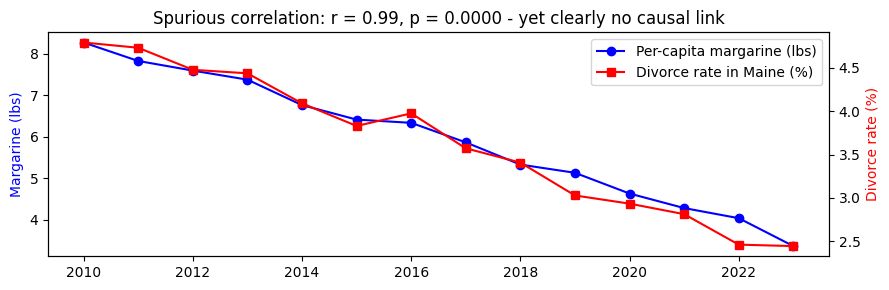

Pearson r = 0.992 p = 0.0000


In [105]:
np.random.seed(42)
t = np.arange(2010, 2024)
margarine = 8.2 - 0.35 * (t - 2010) + np.random.randn(14) * 0.15
divorce_rate = 5.0 - 0.2 * (t - 2010) + np.random.randn(14) * 0.12

fig, ax1 = plt.subplots(figsize=(9, 3))
ax2 = ax1.twinx()
ax1.plot(t, margarine, "b-o", label="Per-capita margarine (lbs)")
ax2.plot(t, divorce_rate, "r-s", label="Divorce rate in Maine (%)")
ax1.set_ylabel("Margarine (lbs)", color="b")
ax2.set_ylabel("Divorce rate (%)", color="r")
r, p = stats.pearsonr(margarine, divorce_rate)
ax1.set_title(f"Spurious correlation: r = {r:.2f}, p = {p:.4f} - yet clearly no causal link")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f} p = {p:.4f}")


Both series share the same downward TIME trend - that is the hidden common cause
(a Fork: TIME -> margarine, TIME -> divorce). Conditioning on time makes the correlation vanish.

> Warning: High correlation + low p-value does NOT mean causation.


---
## 2. The Three Causal Building Blocks

Set `CONFIG["building_block"]` to `"chain"`, `"fork"`, or `"collider"` to switch demos.

| Pattern | Structure | Key property |
|---|---|---|
| Chain | X1 -> X2 -> X3 | X1 _|_ X3 given X2 (mediator blocks) |
| Fork | X2 -> X1, X2 -> X3 | X1 _|_ X3 given X2 (confounder blocks) |
| Collider | X1 -> X2 <- X3 | X1 _|_ X3 marginal, but dependent given X2 |


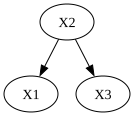

In [106]:
bb = CONFIG["building_block"]
n = CONFIG["n_samples"]

if bb == "chain":
    scm = StructuralCausalModel({
        "X1": lambda n_samples: np.random.binomial(1, 0.5, n_samples),
        "X2": discrete_model(["X1"], {(0,): (0.9, 0.1), (1,): (0.2, 0.8)}),
        "X3": discrete_model(["X2"], {(0,): (0.8, 0.2), (1,): (0.3, 0.7)}),
    })
    true_edges = [("X1", "X2"), ("X2", "X3")]
    treatment, mediator, outcome = "X1", "X2", "X3"

elif bb == "fork":
    scm = StructuralCausalModel({
        "X2": lambda n_samples: np.random.binomial(1, 0.5, n_samples),
        "X1": discrete_model(["X2"], {(0,): (0.8, 0.2), (1,): (0.2, 0.8)}),
        "X3": discrete_model(["X2"], {(0,): (0.7, 0.3), (1,): (0.3, 0.7)}),
    })
    true_edges = [("X2", "X1"), ("X2", "X3")]
    treatment, mediator, outcome = "X1", "X2", "X3"

else: # collider
    scm = StructuralCausalModel({
        "X1": lambda n_samples: np.random.binomial(1, 0.5, n_samples),
        "X3": lambda n_samples: np.random.binomial(1, 0.5, n_samples),
        "X2": discrete_model(["X1", "X3"], {
            (0, 0): (0.9, 0.1), (0, 1): (0.4, 0.6),
            (1, 0): (0.4, 0.6), (1, 1): (0.1, 0.9)}),
    })
    true_edges = [("X1", "X2"), ("X3", "X2")]
    treatment, mediator, outcome = "X1", "X2", "X3"

scm.cgm.draw()


In [107]:
df_bb = scm.sample(n_samples=n)

corr_marg = np.corrcoef(df_bb[treatment], df_bb[outcome])[0, 1]
_, p_marg = stats.pearsonr(df_bb[treatment], df_bb[outcome])
print(f"Marginal {treatment} <-> {outcome}: r = {corr_marg:+.4f} p = {p_marg:.2e}")
print(" -> " + ("DEPENDENT (without conditioning)" if abs(corr_marg) > 0.05 else "INDEPENDENT (without conditioning)"))

for val in [0, 1]:
    sub = df_bb[df_bb[mediator] == val]
    r_c, p_c = stats.pearsonr(sub[treatment], sub[outcome])
    msg = ("Near zero: conditioning blocked the association."
           if abs(r_c) < 0.1 else
           "Non-zero: conditioning OPENED a new association (collider bias)!")
    print(f" Conditional | {mediator}={val}: r = {r_c:+.4f} p = {p_c:.2e} {msg}")

do1 = scm.do(treatment)
df1 = do1.sample(n_samples=n, set_values={treatment: np.ones(n, dtype=int)})
df0 = do1.sample(n_samples=n, set_values={treatment: np.zeros(n, dtype=int)})
ate_true = df1[outcome].mean() - df0[outcome].mean()
print(f"ATE do({treatment}=1 vs 0) = {ate_true:+.4f}")
bb_interp = {
    "chain" : "True causal effect - X1 causes X3 via X2. Controlling X2 (mediator) BLOCKS the effect!",
    "fork" : "SPURIOUS - X2 confounds. True X1->X3 causal effect = 0. Adjust for X2 -> association vanishes.",
    "collider": "Correctly ~0 - X1 and X3 independent. Conditioning on X2 CREATES a fake association!",
}
print(f" ({bb}) {bb_interp[bb]}")


Marginal X1 <-> X3: r = +0.2384 p = 0.00e+00
 -> DEPENDENT (without conditioning)
 Conditional | X2=0: r = -0.0031 p = 6.28e-01 Near zero: conditioning blocked the association.
 Conditional | X2=1: r = +0.0136 p = 3.12e-02 Near zero: conditioning blocked the association.
ATE do(X1=1 vs 0) = +0.0012
 (fork) SPURIOUS - X2 confounds. True X1->X3 causal effect = 0. Adjust for X2 -> association vanishes.


---
## 3. Simpson's Paradox

A trend reverses when subgroups are combined. The cause: a lurking confounder
affects both treatment assignment and outcome.

In the kidney stone example, doctors preferentially assigned treatment A to the
hardest cases (large stones), inflating A's raw failure count. The stone size is
the confounder. Stratifying by stone size (backdoor adjustment) corrects the bias.


Patients: 700 | {'A': 350, 'B': 350} | {'small': 357, 'large': 343}
Aggregated: A=78.0% B=82.6% -> B looks better overall (MISLEADING)
Stratified: Small: A=93.1% B=86.7% -> A wins
 Large: A=73.0% B=68.8% -> A wins
Adjusted ATE: E[Y|do(T=A)]=0.833 E[Y|do(T=B)]=0.779 -> A better by 5.4pp


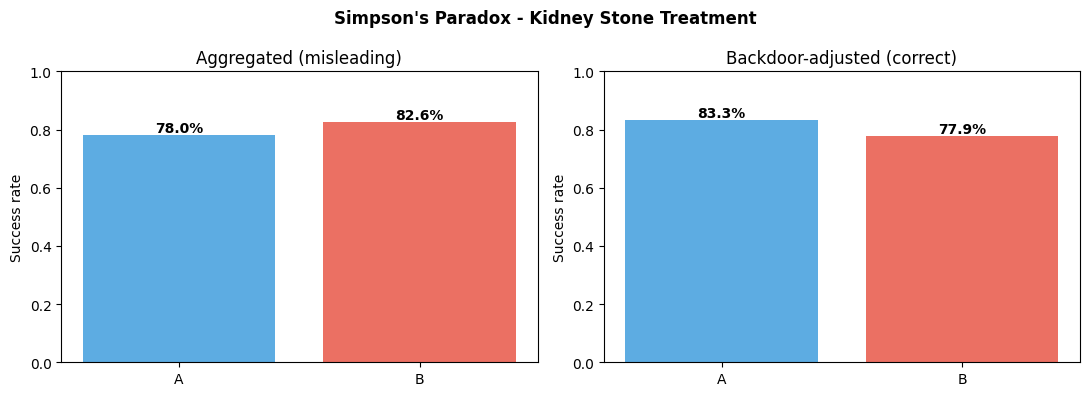

In [108]:
data_sp = {
    "stone" : ["small"] * 357 + ["large"] * 343,
    "treat" : (["A"] * 87 + ["B"] * 270 +
                ["A"] * 263 + ["B"] * 80),
    "success": ([1] * 81 + [0] * 6 + [1] * 234 + [0] * 36 +
                [1] * 192 + [0] * 71 + [1] * 55 + [0] * 25),
}
df_sp = pd.DataFrame(data_sp)
print(f"Patients: {len(df_sp)} | {df_sp['treat'].value_counts().to_dict()} | {df_sp['stone'].value_counts().to_dict()}")

agg = df_sp.groupby("treat")["success"].mean()
print(f"Aggregated: A={agg['A']:.1%} B={agg['B']:.1%} -> B looks better overall (MISLEADING)")

strat = df_sp.groupby(["stone", "treat"])["success"].mean().unstack()
print(f"Stratified: Small: A={strat.loc['small','A']:.1%} B={strat.loc['small','B']:.1%} -> A wins")
print(f" Large: A={strat.loc['large','A']:.1%} B={strat.loc['large','B']:.1%} -> A wins")

p_small = (df_sp["stone"] == "small").mean()
p_large = (df_sp["stone"] == "large").mean()
ate_A = strat.loc["small", "A"] * p_small + strat.loc["large", "A"] * p_large
ate_B = strat.loc["small", "B"] * p_small + strat.loc["large", "B"] * p_large
print(f"Adjusted ATE: E[Y|do(T=A)]={ate_A:.3f} E[Y|do(T=B)]={ate_B:.3f} -> A better by {(ate_A-ate_B)*100:.1f}pp")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, title in zip(axes,
                            [[agg["A"], agg["B"]], [ate_A, ate_B]],
                            ["Aggregated (misleading)", "Backdoor-adjusted (correct)"]):
    ax.bar(["A", "B"], vals, color=["#3498DB", "#E74C3C"], alpha=0.8)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel("Success rate")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
plt.suptitle("Simpson's Paradox - Kidney Stone Treatment", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 4. Backdoor Adjustment

When a confounder `C` opens a backdoor path `T <- C -> Y`, the naive ATE is biased.
The backdoor criterion tells us to adjust for `C` to block that path.

Formula: `E[Y | do(T=t)] = sum_c E[Y | T=t, C=c] * P(C=c)`

Procedure:
1. Identify confounder C (affects both T and Y)
2. Within each C-stratum, treatment is as-good-as-random
3. Compute E[Y|T=t, C=c] within each stratum
4. Weight by the marginal P(C=c) and sum


True ATE (do-calculus): E[Y|do(T=1)]=0.6528 E[Y|do(T=0)]=0.4538 ATE=+0.1991
Naive ATE (observational): E[Y|T=1]=0.7425 E[Y|T=0]=0.3562 ATE=+0.3863 error=+94.1%
Adjusted ATE: E[Y|do(T=1)]=0.6596 E[Y|do(T=0)]=0.4491 ATE=+0.2105 error=+5.8%


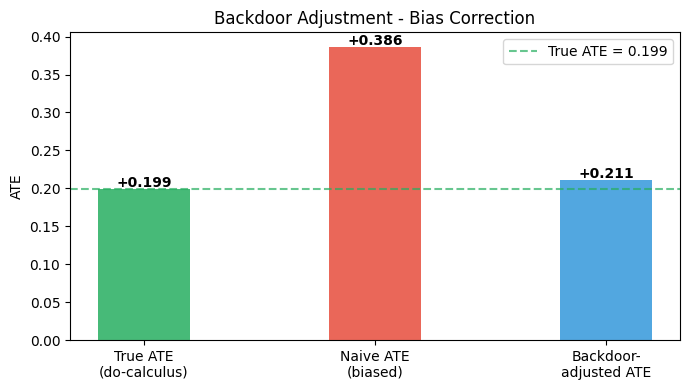

In [109]:
scm_bd = StructuralCausalModel({
    "C": lambda n_samples: np.random.binomial(1, 0.5, n_samples),
    "T": discrete_model(["C"], {(0,): (0.8, 0.2), (1,): (0.2, 0.8)}),
    "Y": discrete_model(["C", "T"], {
        (0, 0): (0.7, 0.3),
        (0, 1): (0.5, 0.5),
        (1, 0): (0.4, 0.6),
        (1, 1): (0.2, 0.8),
    }),
})

do_T = scm_bd.do("T")
df_do1 = do_T.sample(n_samples=50_000, set_values={"T": np.ones(50_000, dtype=int)})
df_do0 = do_T.sample(n_samples=50_000, set_values={"T": np.zeros(50_000, dtype=int)})
true_ate = df_do1["Y"].mean() - df_do0["Y"].mean()
print(f"True ATE (do-calculus): E[Y|do(T=1)]={df_do1['Y'].mean():.4f} E[Y|do(T=0)]={df_do0['Y'].mean():.4f} ATE={true_ate:+.4f}")

df_obs = scm_bd.sample(n_samples=10_000)
naive_ate = df_obs[df_obs["T"] == 1]["Y"].mean() - df_obs[df_obs["T"] == 0]["Y"].mean()
print(f"Naive ATE (observational): E[Y|T=1]={df_obs[df_obs['T']==1]['Y'].mean():.4f} E[Y|T=0]={df_obs[df_obs['T']==0]['Y'].mean():.4f} ATE={naive_ate:+.4f} error={((naive_ate-true_ate)/abs(true_ate)*100):+.1f}%")

p_C0 = (df_obs["C"] == 0).mean()
p_C1 = (df_obs["C"] == 1).mean()
sub_C0 = df_obs[df_obs["C"] == 0]
sub_C1 = df_obs[df_obs["C"] == 1]
adj_y1 = sub_C0[sub_C0["T"] == 1]["Y"].mean() * p_C0 + sub_C1[sub_C1["T"] == 1]["Y"].mean() * p_C1
adj_y0 = sub_C0[sub_C0["T"] == 0]["Y"].mean() * p_C0 + sub_C1[sub_C1["T"] == 0]["Y"].mean() * p_C1
adj_ate = adj_y1 - adj_y0
print(f"Adjusted ATE: E[Y|do(T=1)]={adj_y1:.4f} E[Y|do(T=0)]={adj_y0:.4f} ATE={adj_ate:+.4f} error={((adj_ate-true_ate)/abs(true_ate)*100):+.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
labels = ["True ATE\n(do-calculus)", "Naive ATE\n(biased)", "Backdoor-\nadjusted ATE"]
values = [true_ate, naive_ate, adj_ate]
colors = ["#27AE60", "#E74C3C", "#3498DB"]
bars = ax.bar(labels, values, color=colors, alpha=0.85, width=0.4)
ax.axhline(true_ate, color="#27AE60", linestyle="--", alpha=0.7, label=f"True ATE = {true_ate:.3f}")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003,
            f"{val:+.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("ATE")
ax.set_title("Backdoor Adjustment - Bias Correction")
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. PC Algorithm - Step-by-Step

The PC algorithm learns a causal skeleton from observational data using conditional
independence tests. We walk through every decision below.

### Algorithm overview
```
1. Start: complete undirected graph
2. For k = 0, 1, 2, ... (conditioning-set size)
   For each edge (X,Y):
     For each set Z of neighbours(X)\{Y} with |Z|=k:
       If X _|_ Y | Z (p-value > alpha):
         Remove edge (X,Y); record sep_set(X,Y) = Z
3. Orient v-structures: A-B-C with A,B not adjacent
   If B not in sep_set(A,C) -> orient A->B<-C
4. Propagate orientations (Meek rules)
5. (Optional) apply expert / temporal knowledge
```

Key assumption: No hidden confounders (causal sufficiency).


In [110]:
def pc_stepbystep(data, sig_level, max_cond_vars, verbose=True):
    nodes = list(data.columns)

    G = nx.complete_graph(nodes)
    sep_sets = {}
    skel_steps = []

    for k in range(max_cond_vars + 1):
        removals = []
        for X, Y in list(G.edges()):
            if not G.has_edge(X, Y):
                continue
            nbrs_X = sorted(set(G.neighbors(X)) - {Y})
            if len(nbrs_X) < k:
                continue
            for Z in combinations(nbrs_X, k):
                p = partial_corr_pvalue(data, X, Y, list(Z))
                if p > sig_level:
                    G.remove_edge(X, Y)
                    sep_sets[frozenset([X, Y])] = set(Z)
                    removals.append({"edge": (X, Y), "Z": list(Z), "p": p})
                    break
        skel_steps.append({"k": k, "removals": removals, "graph": G.copy()})

    pdag = nx.DiGraph()
    pdag.add_nodes_from(nodes)
    for u, v in G.edges():
        pdag.add_edge(u, v)
        pdag.add_edge(v, u)

    vstr_steps = []
    oriented_triples = set()
    for B in nodes:
        for A, C in permutations(nodes, 2):
            if A == C or A == B or C == B:
                continue
            if (G.has_edge(A, B) and G.has_edge(C, B)
                    and not G.has_edge(A, C)
                    and frozenset([A, C, B]) not in oriented_triples):
                sep_AC = sep_sets.get(frozenset([A, C]), set())
                if B not in sep_AC:
                    if pdag.has_edge(B, A):
                        pdag.remove_edge(B, A)
                    if pdag.has_edge(B, C):
                        pdag.remove_edge(B, C)
                    oriented_triples.add(frozenset([A, C, B]))
                    vstr_steps.append({
                        "triple" : (A, B, C),
                        "sep_set" : sep_AC,
                        "oriented": [(A, B), (C, B)],
                        "reason" : (f"Unshielded triple {A}-{B}-{C}; "
                                     f"{B} not in sep({A},{C})="
                                     f"{'empty' if not sep_AC else sep_AC}"
                                     f" -> orient {A}->{B}<-{C}")
                    })

    return G, pdag, sep_sets, skel_steps, vstr_steps


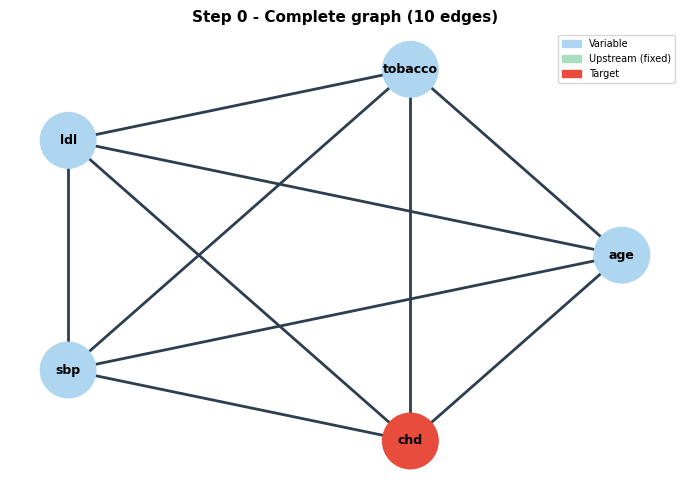

Variables: ['age', 'tobacco', 'ldl', 'sbp', 'chd'] | 10 possible edges | alpha=0.01


In [111]:
np.random.seed(42)
n_pc = 2000
synthetic_pc = pd.DataFrame({
    "age" : np.random.randint(30, 70, n_pc),
    "tobacco": np.random.exponential(2, n_pc),
    "ldl" : np.random.normal(4, 1, n_pc),
    "sbp" : np.random.normal(130, 20, n_pc),
    "chd" : np.zeros(n_pc),
})
synthetic_pc["sbp"] += 0.5 * synthetic_pc["age"]
synthetic_pc["chd"] = (0.04 * synthetic_pc["tobacco"]
                     + 0.1 * synthetic_pc["ldl"]
                     + 0.02 * synthetic_pc["age"]
                     + 0.005 * synthetic_pc["sbp"]
                     + np.random.normal(0, 0.5, n_pc))
synthetic_pc["ldl"] += 0.15 * synthetic_pc["tobacco"]

sig = CONFIG["significance_level"]
mcv = CONFIG["max_cond_vars"]
nodes_pc = list(synthetic_pc.columns)

skeleton, pdag, sep_sets_pc, skel_steps, vstr_steps = pc_stepbystep(
    synthetic_pc, sig, mcv, verbose=True)

pos_pc = nx.circular_layout(nx.complete_graph(nodes_pc))
G_complete = nx.complete_graph(nodes_pc)

fig, ax = plt.subplots(figsize=(7, 5))
draw_graph(G_complete,
           title=f"Step 0 - Complete graph ({G_complete.number_of_edges()} edges)",
           target="chd", pos=pos_pc, ax=ax)
plt.tight_layout()
plt.show()
print(f"Variables: {nodes_pc} | {G_complete.number_of_edges()} possible edges | alpha={sig}")


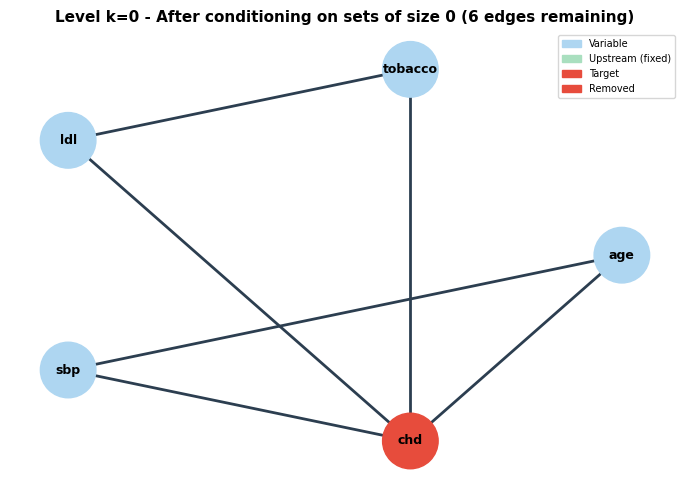

 k=0: removed 4 edge(s) [k=0: unconditional test]
 age-tobacco | Z=empty | p=0.7712 > alpha=0.01
 age-ldl | Z=empty | p=0.8260 > alpha=0.01
 tobacco-sbp | Z=empty | p=0.1774 > alpha=0.01
 ldl-sbp | Z=empty | p=0.2711 > alpha=0.01


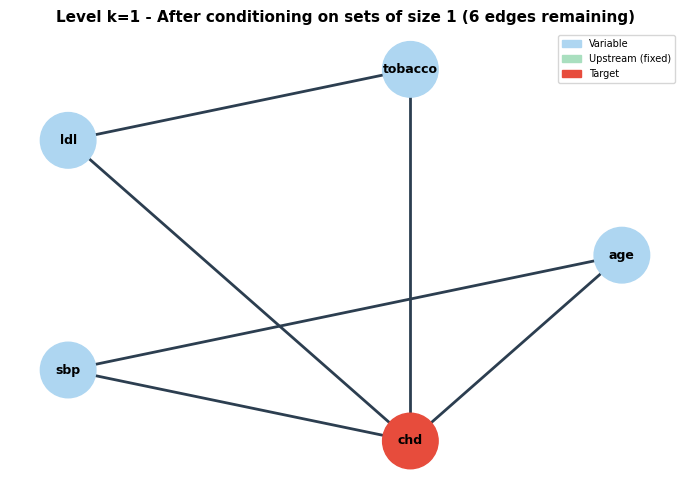

 k=1: no edges removed.


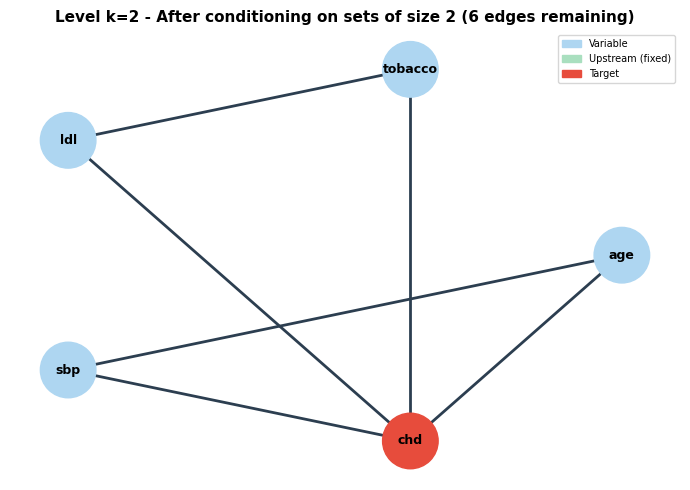

 k=2: no edges removed.


In [112]:
for step in skel_steps:
    k = step["k"]
    removals = step["removals"]
    G_cur = step["graph"]

    fig, ax = plt.subplots(figsize=(7, 5))
    draw_graph(G_cur,
               title=(f"Level k={k} - After conditioning on sets of size {k} "
                      f"({G_cur.number_of_edges()} edges remaining)"),
               highlight_removed=[(r["edge"][0], r["edge"][1]) for r in removals],
               target="chd", pos=pos_pc, ax=ax)
    plt.tight_layout()
    plt.show()

    if not removals:
        print(f" k={k}: no edges removed.")
    else:
        suffix = " [k=0: unconditional test]" if k == 0 else ""
        print(f" k={k}: removed {len(removals)} edge(s){suffix}")
        for r in removals:
            Z_str = "empty" if not r["Z"] else "{" + ", ".join(r["Z"]) + "}"
            print(f" {r['edge'][0]}-{r['edge'][1]} | Z={Z_str} | p={r['p']:.4f} > alpha={sig}")


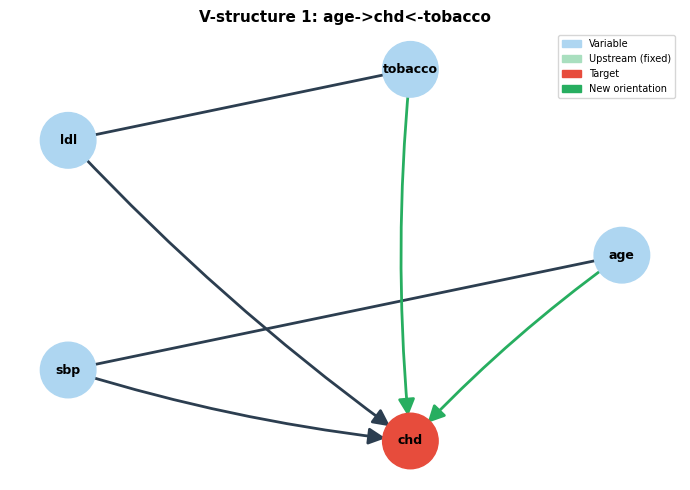

 Unshielded triple age-chd-tobacco; chd not in sep(age,tobacco)=empty -> orient age->chd<-tobacco
 -> chd is a collider: both age and tobacco point INTO it.


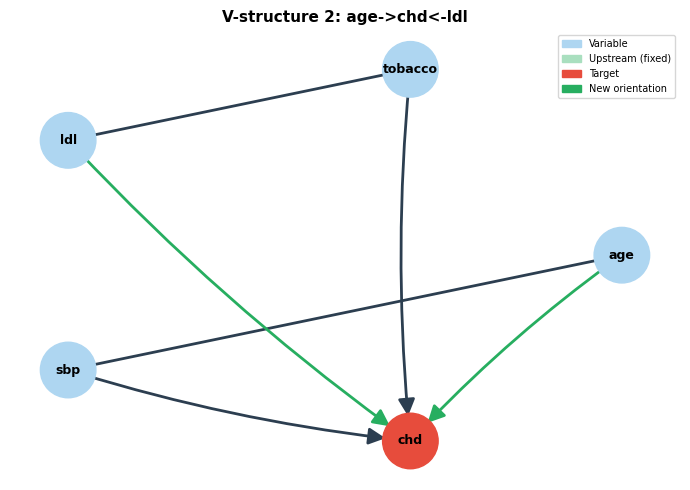

 Unshielded triple age-chd-ldl; chd not in sep(age,ldl)=empty -> orient age->chd<-ldl
 -> chd is a collider: both age and ldl point INTO it.


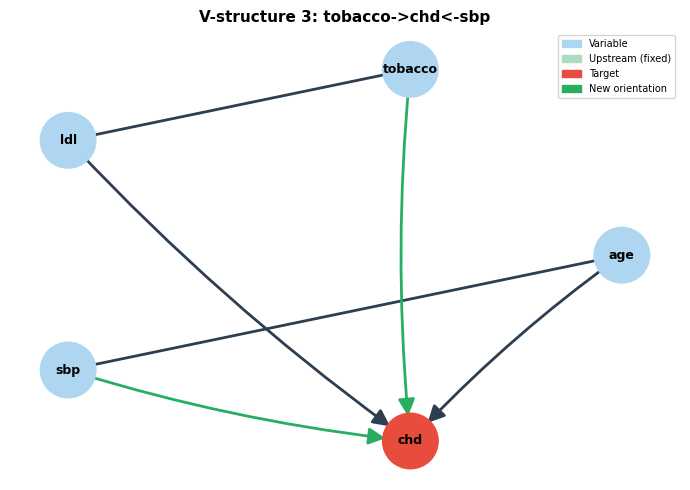

 Unshielded triple tobacco-chd-sbp; chd not in sep(tobacco,sbp)=empty -> orient tobacco->chd<-sbp
 -> chd is a collider: both tobacco and sbp point INTO it.


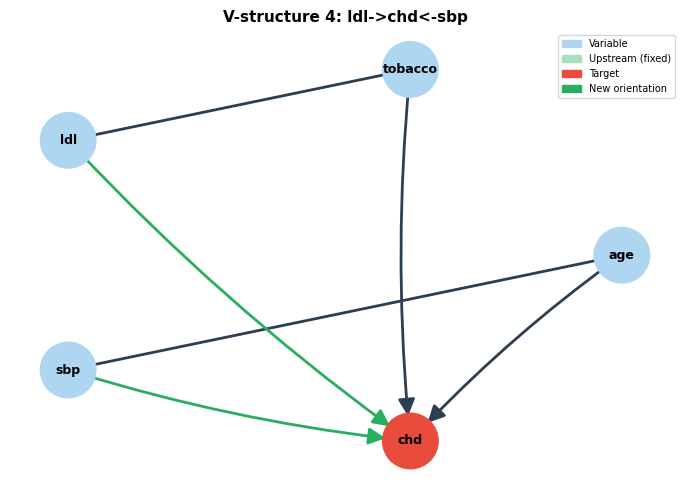

 Unshielded triple ldl-chd-sbp; chd not in sep(ldl,sbp)=empty -> orient ldl->chd<-sbp
 -> chd is a collider: both ldl and sbp point INTO it.

Skeleton edges: 6 | Directed: 4 | Undirected: 2


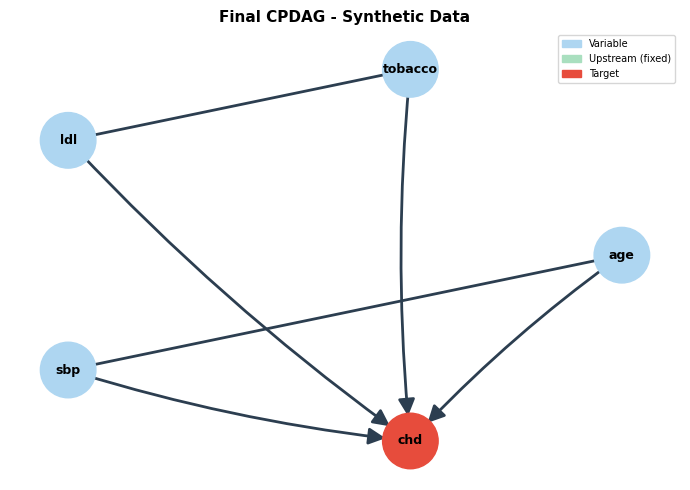

In [113]:
if not vstr_steps:
    print("No unshielded colliders found in the skeleton.")
else:
    for i, vstep in enumerate(vstr_steps):
        A, B, C = vstep["triple"]
        fig, ax = plt.subplots(figsize=(7, 5))
        draw_graph(pdag,
                   title=f"V-structure {i+1}: {A}->{B}<-{C}",
                   highlight_new=vstep["oriented"],
                   target="chd", pos=pos_pc, ax=ax)
        plt.tight_layout()
        plt.show()
        print(f" {vstep['reason']}")
        print(f" -> {B} is a collider: both {A} and {C} point INTO it.")

print(f"\nSkeleton edges: {skeleton.number_of_edges()} | "
      f"Directed: {sum(1 for u,v in pdag.edges() if not pdag.has_edge(v,u))} | "
      f"Undirected: {sum(1 for u,v in pdag.edges() if pdag.has_edge(v,u))//2}")

fig, ax = plt.subplots(figsize=(7, 5))
draw_graph(pdag, title="Final CPDAG - Synthetic Data", target="chd", pos=pos_pc, ax=ax)
plt.tight_layout()
plt.show()


---
## 6. PC Algorithm on South-African Heart Disease Data

We can get some actual logic upstream directly, so it's easier imo:

Expert knowledge injected (temporal ordering):
- Layer 1 (upstream): `age`, `famhist` - cannot be caused by other variables
- Layer 2 (mediators): `sbp`, `tobacco`, `ldl`, `adiposity`, `typea`, `alcohol`
- Layer 3 (outcome): `chd`


Shape: (462, 9) | Variables: ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'alcohol', 'age', 'chd'] | CHD prevalence: 34.6%


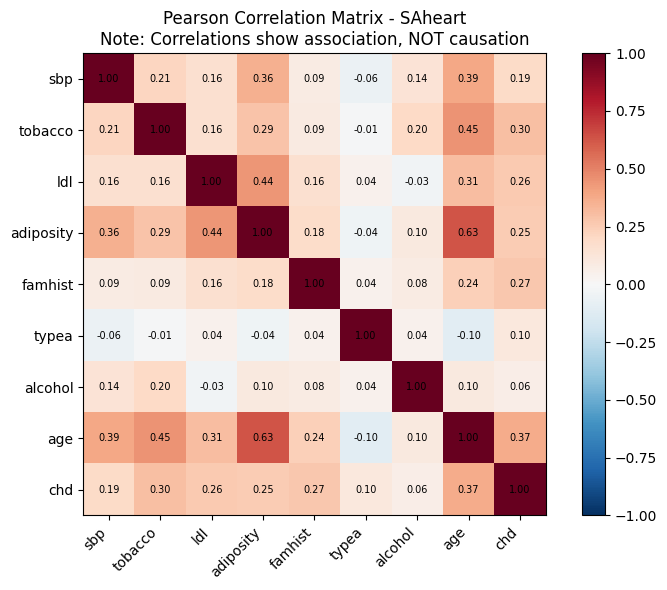

In [114]:
df_heart = pd.read_csv(CONFIG["dataset_path"])
df_heart = df_heart.drop(columns=["row.names", "obesity"], errors="ignore")
df_heart["famhist"] = df_heart["famhist"].map({"Absent": 0, "Present": 1})
if df_heart["chd"].dtype == object:
    df_heart["chd"] = df_heart["chd"].map({"No": 0, "Si": 1})
df_heart.dropna(inplace=True)
print(f"Shape: {df_heart.shape} | Variables: {list(df_heart.columns)} | CHD prevalence: {df_heart['chd'].mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 6))
corr_mat = df_heart.corr()
im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_mat)))
ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_mat)))
ax.set_yticklabels(corr_mat.columns)
plt.colorbar(im, ax=ax)
for i in range(len(corr_mat)):
    for j in range(len(corr_mat)):
        ax.text(j, i, f"{corr_mat.values[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Pearson Correlation Matrix - SAheart\nNote: Correlations show association, NOT causation")
plt.tight_layout()
plt.show()


High correlations worth noting:
- `age <-> chd` r ≈ 0.45 - age is a primary risk factor
- `ldl <-> adiposity` r ≈ 0.44 - metabolic co-variation
- `age <-> sbp` r ≈ 0.37 - blood pressure rises with age

These correlations are observational - they may be driven by confounders,
common causes, or causal chains. The PC algorithm below separates signal from structure.

> Warning: Correlation alone cannot tell us which variable causes which.


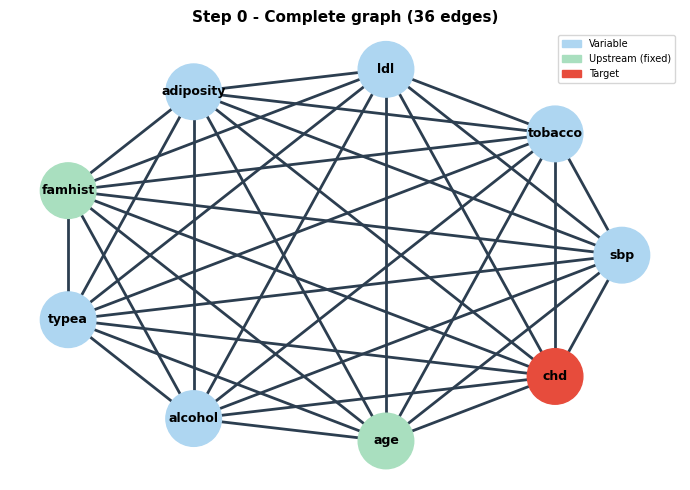

36 edges initially | alpha=0.01


In [115]:
nodes_h = list(df_heart.columns)
sig_h = CONFIG["significance_level"]
mcv_h = CONFIG["max_cond_vars"]
upstream = ["age", "famhist"]

skel_h, pdag_h, sep_h, skel_steps_h, vstr_steps_h = pc_stepbystep(df_heart, sig_h, mcv_h)

pos_h = nx.circular_layout(nx.complete_graph(nodes_h))
G_comp_h = nx.complete_graph(nodes_h)
fig, ax = plt.subplots(figsize=(7, 5))
draw_graph(G_comp_h,
           title=f"Step 0 - Complete graph ({G_comp_h.number_of_edges()} edges)",
           target="chd", upstream=upstream, pos=pos_h, ax=ax)
plt.tight_layout()
plt.show()
print(f"{G_comp_h.number_of_edges()} edges initially | alpha={sig_h}")


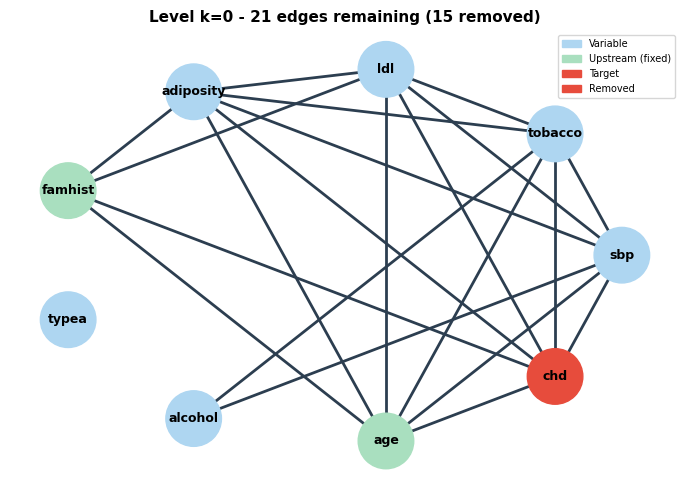

 k=0: 15 edge(s) removed:
 sbp-famhist | Z=empty | p=0.0659
 sbp-typea | Z=empty | p=0.2177
 tobacco-famhist | Z=empty | p=0.0570
 tobacco-typea | Z=empty | p=0.7542
 ldl-typea | Z=empty | p=0.3448
 ldl-alcohol | Z=empty | p=0.4738
 adiposity-typea | Z=empty | p=0.3548
 adiposity-alcohol | Z=empty | p=0.0311
 famhist-typea | Z=empty | p=0.3366
 famhist-alcohol | Z=empty | p=0.0838
 typea-alcohol | Z=empty | p=0.3970
 typea-age | Z=empty | p=0.0274
 typea-chd | Z=empty | p=0.0266
 alcohol-age | Z=empty | p=0.0298
 alcohol-chd | Z=empty | p=0.1797


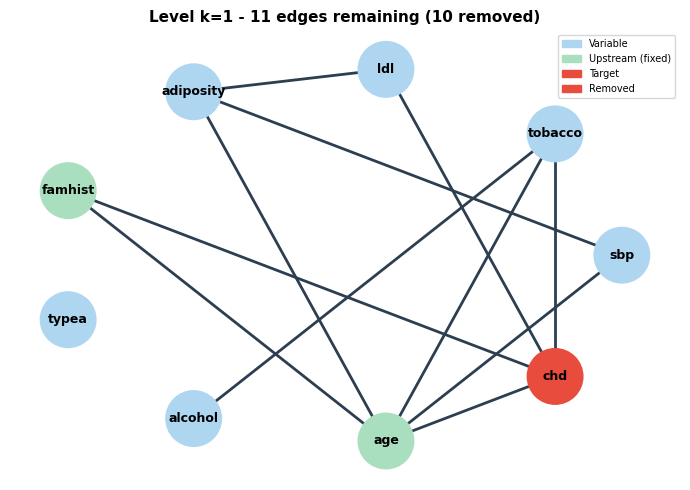

 k=1: 10 edge(s) removed:
 sbp-tobacco | Z={age} | p=0.3325
 sbp-ldl | Z={adiposity} | p=0.9739
 sbp-alcohol | Z={adiposity} | p=0.0158
 sbp-chd | Z={adiposity} | p=0.0154
 tobacco-ldl | Z={adiposity} | p=0.4155
 tobacco-adiposity | Z={age} | p=0.8836
 ldl-famhist | Z={adiposity} | p=0.0479
 ldl-age | Z={adiposity} | p=0.2686
 adiposity-famhist | Z={age} | p=0.3692
 adiposity-chd | Z={age} | p=0.5405


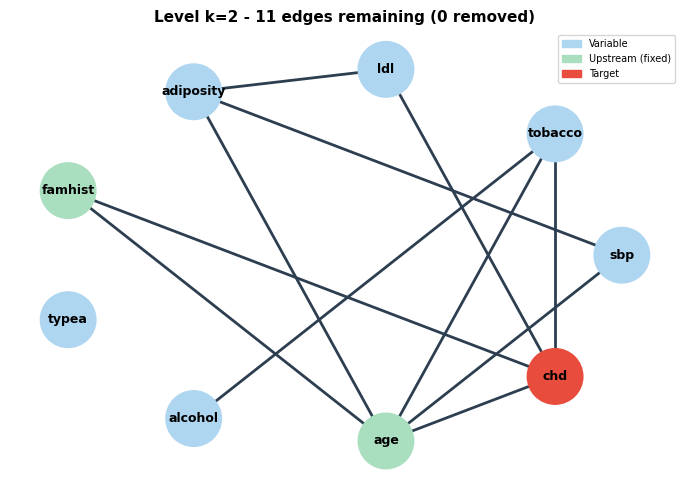

 k=2: no further edges removed.


In [116]:
for step in skel_steps_h:
    k = step["k"]
    removals = step["removals"]
    G_cur = step["graph"]

    fig, ax = plt.subplots(figsize=(7, 5))
    draw_graph(G_cur,
               title=(f"Level k={k} - {G_cur.number_of_edges()} edges remaining "
                      f"({len(removals)} removed)"),
               highlight_removed=[(r["edge"][0], r["edge"][1]) for r in removals],
               target="chd", upstream=upstream, pos=pos_h, ax=ax)
    plt.tight_layout()
    plt.show()

    if not removals:
        print(f" k={k}: no further edges removed.")
    else:
        print(f" k={k}: {len(removals)} edge(s) removed:")
        for r in removals:
            Z_str = "empty" if not r["Z"] else "{" + ", ".join(r["Z"]) + "}"
            print(f" {r['edge'][0]}-{r['edge'][1]} | Z={Z_str} | p={r['p']:.4f}")


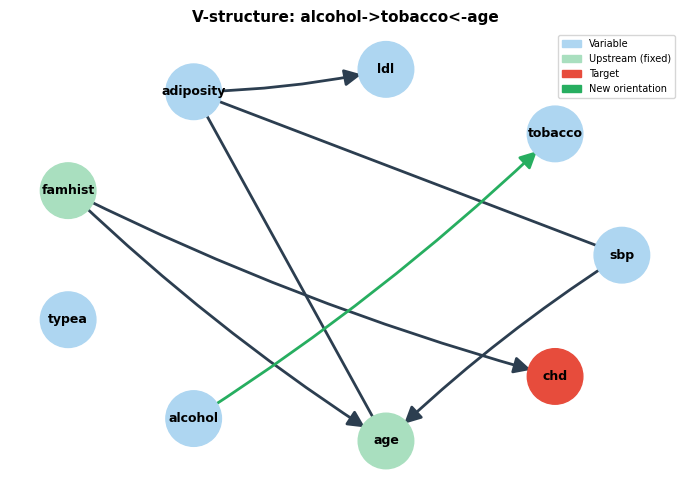

 Unshielded triple alcohol-tobacco-age; tobacco not in sep(alcohol,age)=empty -> orient alcohol->tobacco<-age


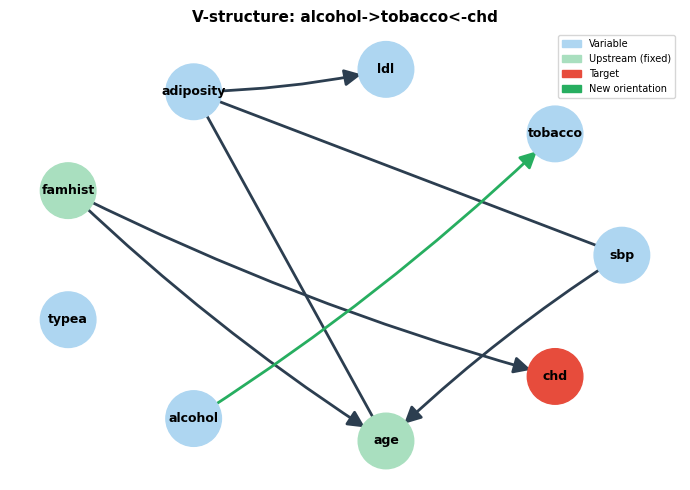

 Unshielded triple alcohol-tobacco-chd; tobacco not in sep(alcohol,chd)=empty -> orient alcohol->tobacco<-chd


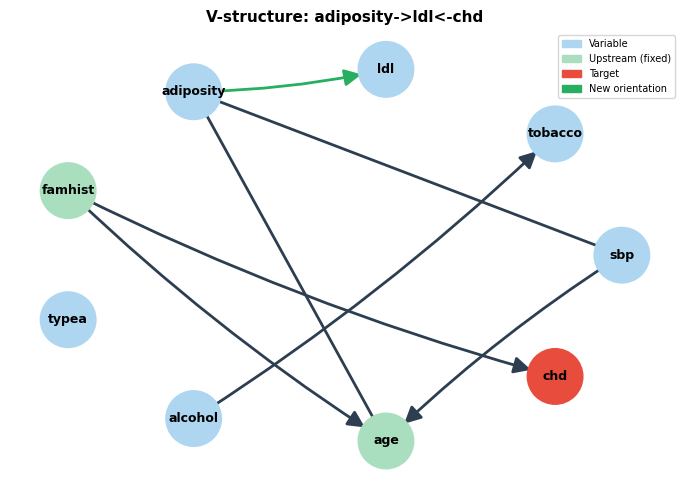

 Unshielded triple adiposity-ldl-chd; ldl not in sep(adiposity,chd)={'age'} -> orient adiposity->ldl<-chd


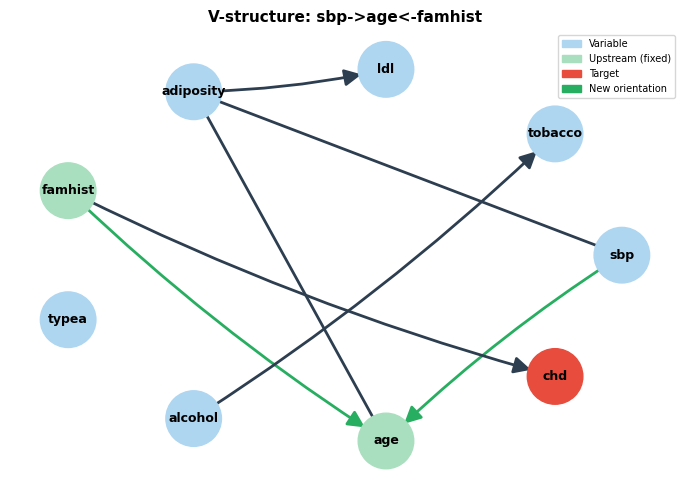

 Unshielded triple sbp-age-famhist; age not in sep(sbp,famhist)=empty -> orient sbp->age<-famhist


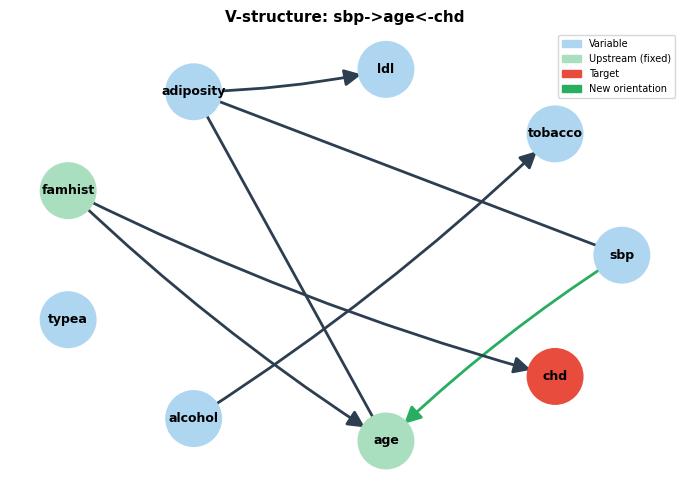

 Unshielded triple sbp-age-chd; age not in sep(sbp,chd)={'adiposity'} -> orient sbp->age<-chd


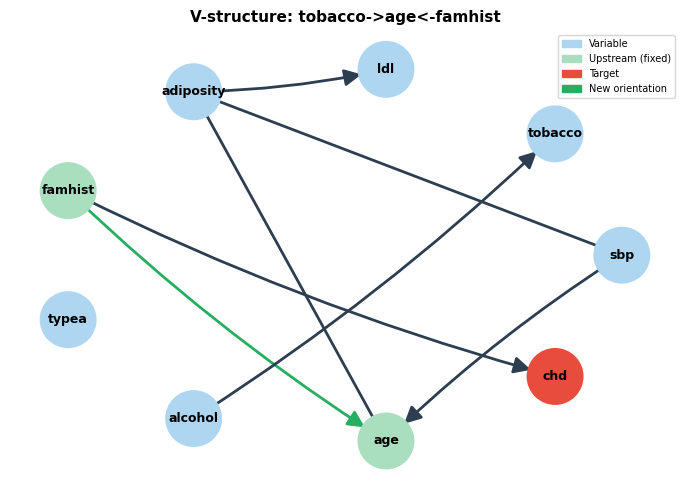

 Unshielded triple tobacco-age-famhist; age not in sep(tobacco,famhist)=empty -> orient tobacco->age<-famhist


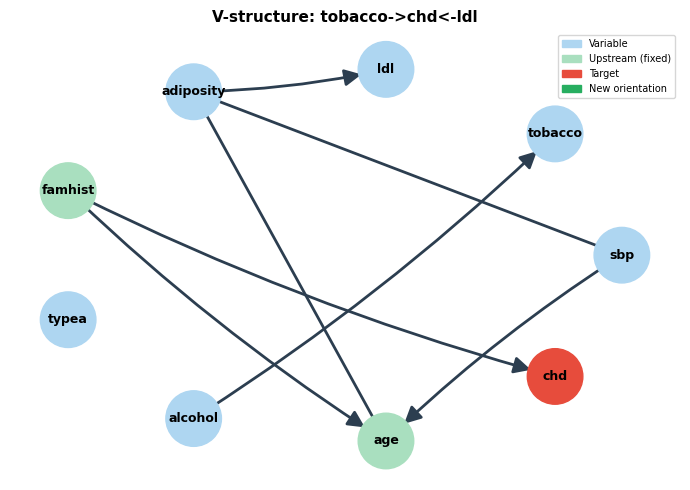

 Unshielded triple tobacco-chd-ldl; chd not in sep(tobacco,ldl)={'adiposity'} -> orient tobacco->chd<-ldl


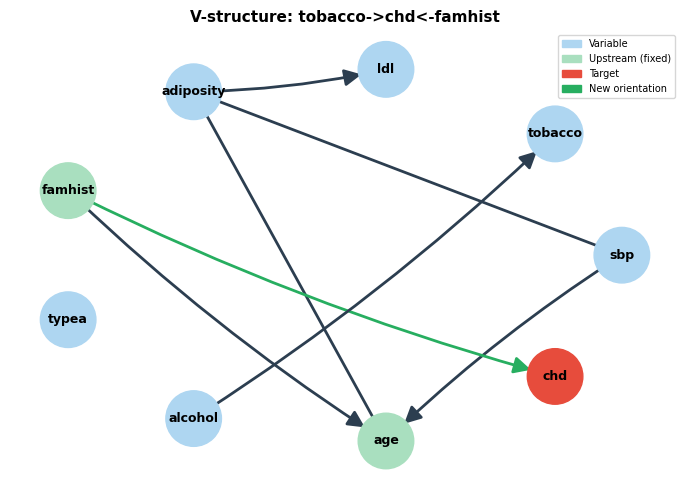

 Unshielded triple tobacco-chd-famhist; chd not in sep(tobacco,famhist)=empty -> orient tobacco->chd<-famhist


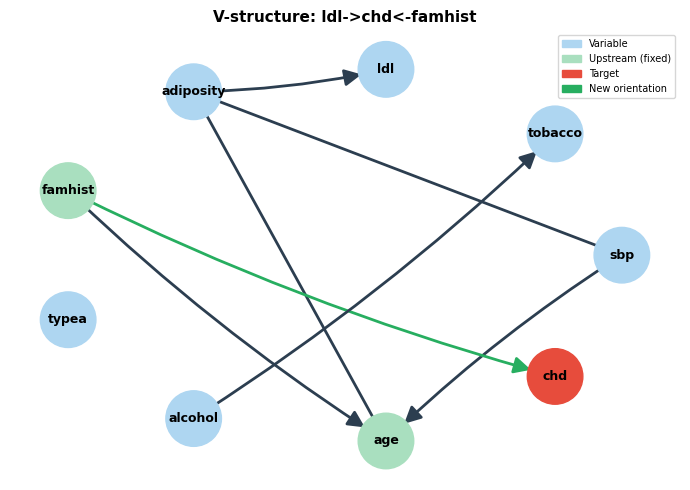

 Unshielded triple ldl-chd-famhist; chd not in sep(ldl,famhist)={'adiposity'} -> orient ldl->chd<-famhist


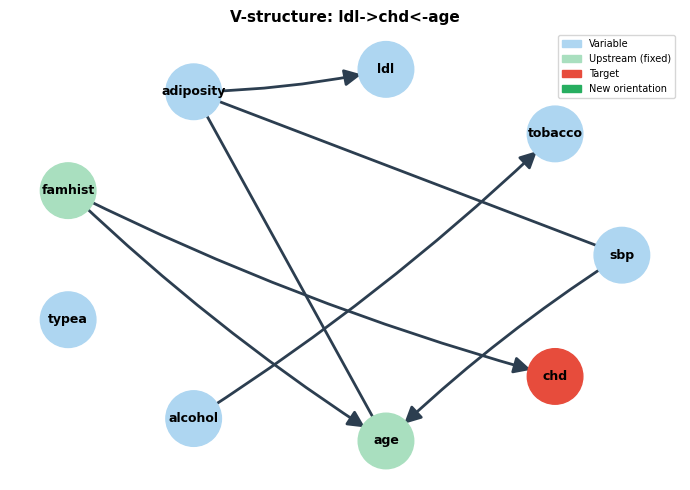

 Unshielded triple ldl-chd-age; chd not in sep(ldl,age)={'adiposity'} -> orient ldl->chd<-age


  0%|          | 0/2 [00:00<?, ?it/s]

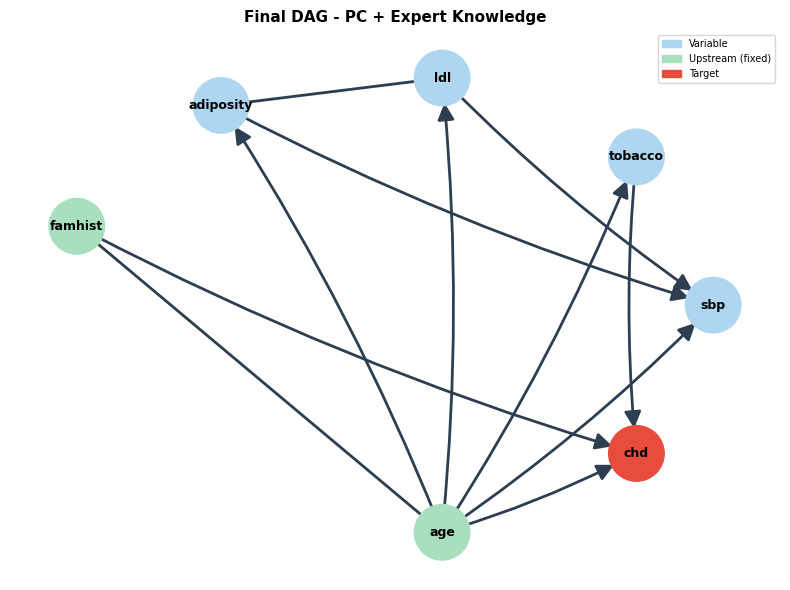

Temporal ordering: [age,famhist] -> [sbp,tobacco,ldl,adiposity,typea,alcohol] -> [chd]
Learned directed edges: [('adiposity', 'ldl'), ('adiposity', 'sbp'), ('age', 'adiposity'), ('age', 'chd'), ('age', 'famhist'), ('age', 'ldl'), ('age', 'sbp'), ('age', 'tobacco'), ('famhist', 'age'), ('famhist', 'chd'), ('ldl', 'adiposity'), ('ldl', 'sbp'), ('tobacco', 'chd')]


In [117]:
if vstr_steps_h:
    for vstep in vstr_steps_h:
        A, B, C = vstep["triple"]
        fig, ax = plt.subplots(figsize=(7, 5))
        draw_graph(pdag_h,
                   title=f"V-structure: {A}->{B}<-{C}",
                   highlight_new=vstep["oriented"],
                   target="chd", upstream=upstream, pos=pos_h, ax=ax)
        plt.tight_layout()
        plt.show()
        print(f" {vstep['reason']}")
else:
    print("No unshielded v-structures found.")

if CONFIG["use_expert_knowledge"]:
    from pgmpy.estimators import ExpertKnowledge, PC as PGMPyPC
    ek = ExpertKnowledge(temporal_order=[
        ["age", "famhist"],
        [c for c in nodes_h if c not in ["age", "famhist", "chd"]],
        ["chd"],
    ])
    pc_pgmpy = PGMPyPC(df_heart)
    model_pgmpy = pc_pgmpy.estimate(
        significance_level=sig_h,
        max_cond_vars=mcv_h,
        expert_knowledge=ek,
        enforce_expert_knowledge=True,
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    draw_graph(nx.DiGraph(model_pgmpy.edges()),
               title="Final DAG - PC + Expert Knowledge",
               target="chd", upstream=upstream, pos=pos_h, ax=ax)
    plt.tight_layout()
    plt.show()
    print("Temporal ordering: [age,famhist] -> [sbp,tobacco,ldl,adiposity,typea,alcohol] -> [chd]")
    print("Learned directed edges:", sorted(model_pgmpy.edges()))


---
## 7. Quality & Quantity Evaluation

### Synthetic data - comparison with ground truth

For the synthetic dataset we know the true causal graph, so we can compute
standard graph-recovery metrics.

| Metric | Formula | Meaning |
|---|---|---|
| Precision | TP / (TP + FP) | Of learned edges, how many are correct? |
| Recall | TP / (TP + FN) | Of true edges, how many did we find? |
| F1 | 2*P*R / (P+R) | Harmonic mean - balance of both |
| SHD | FP + FN | Structural Hamming Distance - total edge errors |

### Real data - structure score

Without ground truth we use the BIC (Bayesian Information Criterion) of the
learned Bayesian network as a proxy: less-negative BIC = better fit with less complexity.

Note: A good structure score does not prove causality - it means the graph is
statistically consistent with the data, not that we have correctly identified
causal directions.


Synthetic skeleton quality:
 True edges=6 Learned=6 TP=6 FP=0 FN=0
 Precision=1.000 Recall=1.000 F1=1.000 SHD=0


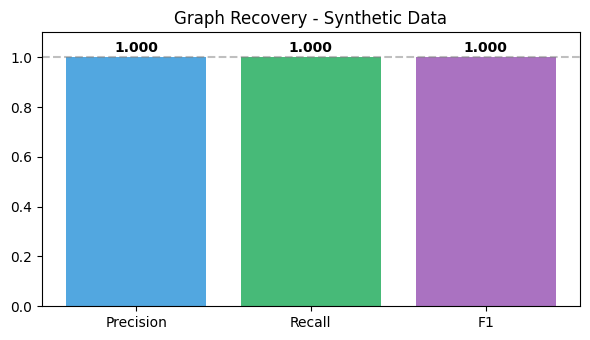

In [118]:
true_synthetic = [
    ("tobacco", "ldl"),
    ("tobacco", "chd"),
    ("ldl", "chd"),
    ("age", "chd"),
    ("age", "sbp"),
    ("sbp", "chd"),
]

q = graph_quality(skeleton, true_synthetic, nodes_pc)
print(f"Synthetic skeleton quality:")
print(f" True edges={len(true_synthetic)} Learned={skeleton.number_of_edges()} TP={q['TP']} FP={q['FP']} FN={q['FN']}")
print(f" Precision={q['Precision']:.3f} Recall={q['Recall']:.3f} F1={q['F1']:.3f} SHD={q['SHD']}")
if q["Precision"] < 1 or q["Recall"] < 1:
    print(" Note: Precision<1 -> spurious edges; Recall<1 -> missed edges (strict alpha or small n)")

fig, ax = plt.subplots(figsize=(6, 3.5))
metrics = ["Precision", "Recall", "F1"]
vals = [q[m] for m in metrics]
ax.bar(metrics, vals, color=["#3498DB", "#27AE60", "#9B59B6"], alpha=0.85)
ax.set_ylim(0, 1.1)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Graph Recovery - Synthetic Data")
plt.tight_layout()
plt.show()


In [119]:
try:
    from pgmpy.structure_score import BicScore
    bic = BicScore(df_heart)
    bic_val = bic.score(model_pgmpy)
    print(f"BIC score: {bic_val:.2f} (less negative = better) | edges={model_pgmpy.number_of_edges()}")
except Exception:
    print(f"BicScore unavailable | edges: {sorted(model_pgmpy.edges())}")

print()
print(f"{'Edge':25s} | In model? | Medical plausibility")
print("-" * 72)
for (u, v), note in [
    (("tobacco","chd"), "Strong direct cause - well established"),
    (("famhist","chd"), "Genetic predisposition - direct risk factor"),
    (("age","chd"), "Age is a primary non-modifiable risk factor"),
    (("ldl","chd"), "Metabolic pathway: high LDL -> artery plaques"),
    (("age","sbp"), "Blood pressure rises with age"),
    (("adiposity","ldl"), "Body fat drives cholesterol levels"),
    (("alcohol","chd"), "Weak/confounded signal in this dataset"),
    (("typea","chd"), "Stress -> cortisol -> cardiovascular strain"),
]:
    present = "[x]" if model_pgmpy.has_edge(u, v) else "[ ]"
    print(f" {u} -> {v:12s} | {present:7s} | {note}")

print()
print(f"Dataset: SAheart (n={len(df_heart)}, {len(nodes_h)} variables) alpha={sig_h} max_cond_vars={mcv_h}")
print(f"Learned edges: {sorted(model_pgmpy.edges())}")
print(f"CHD direct causes: {sorted(u for u,v in model_pgmpy.edges() if v=='chd')}")


BicScore unavailable | edges: [('adiposity', 'ldl'), ('adiposity', 'sbp'), ('age', 'adiposity'), ('age', 'chd'), ('age', 'famhist'), ('age', 'ldl'), ('age', 'sbp'), ('age', 'tobacco'), ('famhist', 'age'), ('famhist', 'chd'), ('ldl', 'adiposity'), ('ldl', 'sbp'), ('tobacco', 'chd')]

Edge                      | In model? | Medical plausibility
------------------------------------------------------------------------
 tobacco -> chd          | [x]     | Strong direct cause - well established
 famhist -> chd          | [x]     | Genetic predisposition - direct risk factor
 age -> chd          | [x]     | Age is a primary non-modifiable risk factor
 ldl -> chd          | [ ]     | Metabolic pathway: high LDL -> artery plaques
 age -> sbp          | [x]     | Blood pressure rises with age
 adiposity -> ldl          | [x]     | Body fat drives cholesterol levels
 alcohol -> chd          | [ ]     | Weak/confounded signal in this dataset
 typea -> chd          | [ ]     | Stress -> cortisol ->

---
## 8. Reading the Final Causal Graph - Plain-English Interpretation

A directed edge A -> B means: *"A is a direct cause of B in this model,
after accounting for all other observed variables."*

### Structural roles

Upstream drivers (`age`, `famhist`) - root causes, biology and genetics.
Cannot be modified but set the baseline risk for every downstream variable.

Mediators (`sbp`, `tobacco`, `ldl`, `adiposity`, `typea`, `alcohol`) - sit
between upstream drivers and CHD. Interventions here (e.g. lowering LDL, quitting
tobacco) can break causal chains even when age and family history are unfavourable.

CHD - the outcome. Its direct causes are the variables with edges pointing into it.

### What this model cannot tell us

- It assumes no hidden confounders (causal sufficiency). Socioeconomic status,
  diet, exercise, and stress are all potentially missing - their absence can bias
  every edge.
- Learned edges are statistically consistent with the data, not proven causal.
- Sample size n = 462 limits power to detect weak effects reliably.

> Reminder: A perfect r = 1.0 with p < 0.0001 still proves nothing about
> causation without a structural argument or a randomised experiment.


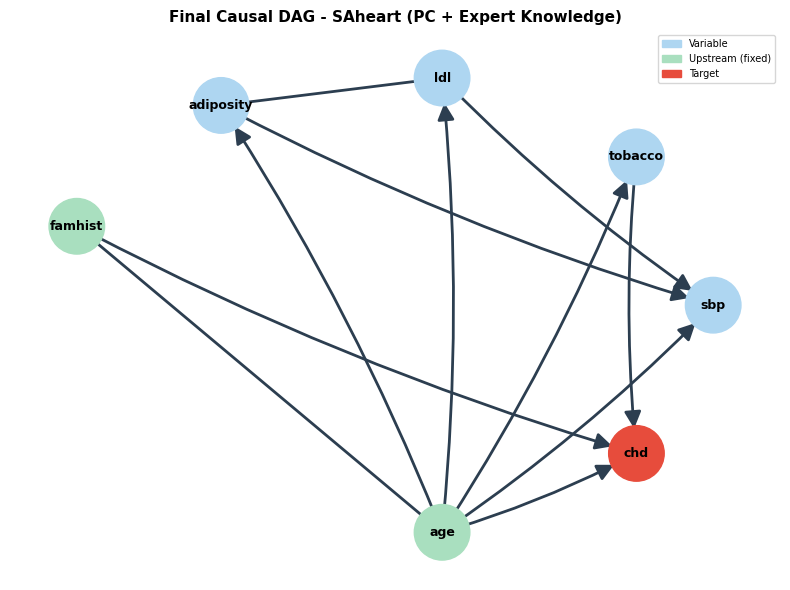

Direct causes of CHD: ['age', 'famhist', 'tobacco']

 adiposity    -> ldl          | body fat drives cholesterol production
 adiposity    -> sbp          | excess fat raises blood pressure via volume load
 age          -> adiposity    | body composition shifts with ageing
 age          -> chd          | ageing directly increases CHD probability
 age          -> famhist      | association detected - direction set by expert knowledge
 age          -> ldl          | cholesterol dysregulation increases with age
 age          -> sbp          | blood pressure naturally rises with age
 age          -> tobacco      | association detected - direction set by expert knowledge
 famhist      -> age          | association detected - direction set by expert knowledge
 famhist      -> chd          | genetic predisposition - family history is non-modifiable
 ldl          -> adiposity    | lipid metabolism and fat storage are linked
 ldl          -> sbp          | association detected - direction set by

In [120]:
fig, ax = plt.subplots(figsize=(8, 6))
draw_graph(nx.DiGraph(model_pgmpy.edges()),
           title="Final Causal DAG - SAheart (PC + Expert Knowledge)",
           target="chd", upstream=["age", "famhist"], pos=pos_h, ax=ax)
plt.tight_layout()
plt.show()

edges = sorted(model_pgmpy.edges())
chd_direct = sorted(u for u, v in edges if v == "chd")
mediators = sorted(set(v for u, v in edges if u in ["age", "famhist"]) - {"chd"})

EDGE_MEANING = {
    ("tobacco", "chd") : "smoking is a well-established direct cardiac risk factor",
    ("famhist", "chd") : "genetic predisposition - family history is non-modifiable",
    ("age", "chd") : "ageing directly increases CHD probability",
    ("ldl", "chd") : "high LDL leads to arterial plaque build-up",
    ("sbp", "chd") : "high systolic BP strains the heart",
    ("typea", "chd") : "Type-A behaviour -> cortisol -> cardiovascular strain",
    ("adiposity","chd") : "body fat percentage influences cardiac risk",
    ("alcohol", "chd") : "complex, often confounded effect on CHD",
    ("age", "sbp") : "blood pressure naturally rises with age",
    ("age", "ldl") : "cholesterol dysregulation increases with age",
    ("age", "adiposity"): "body composition shifts with ageing",
    ("age", "typea") : "age may correlate with personality risk profiles",
    ("tobacco", "ldl") : "smoking raises LDL cholesterol levels",
    ("tobacco", "sbp") : "nicotine acutely raises blood pressure",
    ("tobacco", "adiposity"): "smoking affects metabolism and body composition",
    ("famhist", "ldl") : "genetic factors influence cholesterol metabolism",
    ("famhist", "sbp") : "heritable hypertension pathways",
    ("famhist", "adiposity"): "genetic body-composition tendencies",
    ("ldl", "adiposity"): "lipid metabolism and fat storage are linked",
    ("adiposity","ldl") : "body fat drives cholesterol production",
    ("adiposity","sbp") : "excess fat raises blood pressure via volume load",
    ("sbp", "ldl") : "vascular stiffness and lipid co-regulation",
}

print(f"Direct causes of CHD: {chd_direct}")
print()
for u, v in edges:
    meaning = EDGE_MEANING.get((u, v), "association detected - direction set by expert knowledge")
    print(f" {u:12s} -> {v:12s} | {meaning}")


---
## 9. Investigating Misleading Edges - Why the Algorithm Gets Confused

The PC algorithm is statistically correct given its assumptions, but data patterns can
produce edges that are non-causal, misdirected, or spurious. We investigate four cases.

| Edge | Problem | Root cause |
|---|---|---|
| age vs famhist | Neither causes the other | Ascertainment bias |
| age vs tobacco | Direction misleading | Tobacco is cumulative kg - grows mechanically with age |
| ldl vs adiposity | Direction likely reversed | Symmetric correlation, no v-structure to orient |
| ldl vs sbp | Largely spurious | Shared metabolic confounder (adiposity) |


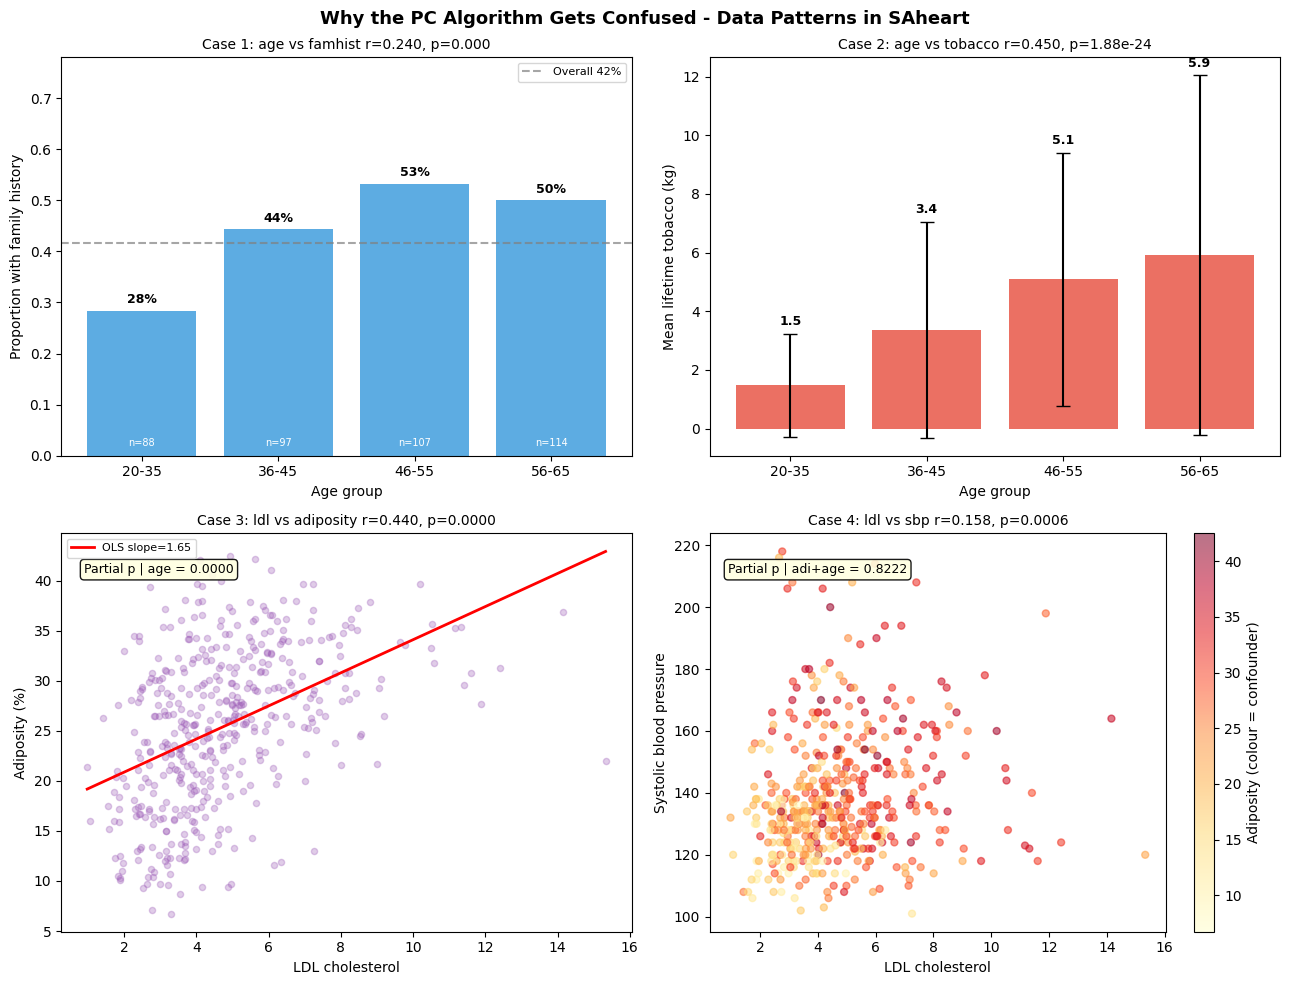

In [121]:
r_af, p_af = stats.pearsonr(df_heart["age"], df_heart["famhist"])
r_at, p_at = stats.pearsonr(df_heart["age"], df_heart["tobacco"])
r_la, p_la = stats.pearsonr(df_heart["ldl"], df_heart["adiposity"])
p_la_cond = partial_corr_pvalue(df_heart, "ldl", "adiposity", ["age"])
r_ls, p_ls = stats.pearsonr(df_heart["ldl"], df_heart["sbp"])
p_ls_adj = partial_corr_pvalue(df_heart, "ldl", "sbp", ["adiposity", "age"])

age_bins = pd.cut(df_heart["age"], bins=[20, 35, 45, 55, 65, 80],
                  labels=["20-35", "36-45", "46-55", "56-65", "66+"])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Why the PC Algorithm Gets Confused - Data Patterns in SAheart",
             fontweight="bold", fontsize=13)

ax = axes[0, 0]
fh_rate = df_heart.groupby(age_bins, observed=True)["famhist"].mean()
fh_n = df_heart.groupby(age_bins, observed=True).size()
ax.bar(range(len(fh_rate)), fh_rate.values, color="#3498DB", alpha=0.8,
       tick_label=fh_rate.index.tolist())
for i, (v, n) in enumerate(zip(fh_rate.values, fh_n.values)):
    ax.text(i, v + 0.015, f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")
    ax.text(i, 0.02, f"n={n}", ha="center", fontsize=7, color="white")
ax.axhline(df_heart["famhist"].mean(), color="gray", linestyle="--", alpha=0.7,
           label=f"Overall {df_heart['famhist'].mean():.0%}")
ax.set_ylim(0, 0.78)
ax.set_ylabel("Proportion with family history")
ax.set_xlabel("Age group")
ax.legend(fontsize=8)
ax.set_title(f"Case 1: age vs famhist r={r_af:.3f}, p={p_af:.3f}", fontsize=10)

ax = axes[0, 1]
tob_mean = df_heart.groupby(age_bins, observed=True)["tobacco"].mean()
tob_std = df_heart.groupby(age_bins, observed=True)["tobacco"].std()
ax.bar(range(len(tob_mean)), tob_mean.values, color="#E74C3C", alpha=0.8,
       tick_label=tob_mean.index.tolist(),
       yerr=tob_std.values, capsize=5, error_kw={"elinewidth": 1.5})
for i, v in enumerate(tob_mean.values):
    ax.text(i, v + tob_std.values[i] + 0.3, f"{v:.1f}", ha="center",
            fontsize=9, fontweight="bold")
ax.set_ylabel("Mean lifetime tobacco (kg)")
ax.set_xlabel("Age group")
ax.set_title(f"Case 2: age vs tobacco r={r_at:.3f}, p={p_at:.2e}", fontsize=10)

ax = axes[1, 0]
ax.scatter(df_heart["ldl"], df_heart["adiposity"], alpha=0.3, color="#9B59B6", s=20)
m, b = np.polyfit(df_heart["ldl"], df_heart["adiposity"], 1)
xl = np.linspace(df_heart["ldl"].min(), df_heart["ldl"].max(), 100)
ax.plot(xl, m * xl + b, "r-", linewidth=2, label=f"OLS slope={m:.2f}")
ax.set_xlabel("LDL cholesterol")
ax.set_ylabel("Adiposity (%)")
ax.set_title(f"Case 3: ldl vs adiposity r={r_la:.3f}, p={p_la:.4f}", fontsize=10)
ax.text(0.04, 0.90, f"Partial p | age = {p_la_cond:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))
ax.legend(fontsize=8)

ax = axes[1, 1]
sc = ax.scatter(df_heart["ldl"], df_heart["sbp"],
                c=df_heart["adiposity"], cmap="YlOrRd", alpha=0.55, s=25)
ax.set_xlabel("LDL cholesterol")
ax.set_ylabel("Systolic blood pressure")
ax.set_title(f"Case 4: ldl vs sbp r={r_ls:.3f}, p={p_ls:.4f}", fontsize=10)
ax.text(0.04, 0.90, f"Partial p | adi+age = {p_ls_adj:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))
plt.colorbar(sc, ax=ax, label="Adiposity (colour = confounder)")

plt.tight_layout()
plt.show()


### Case 1 - age vs famhist: association without causation

Why a statistical edge appears even though neither causes the other:

1. Ascertainment bias - this is a retrospective cohort (1980s South Africa).
   Older patients have had more relatives reach CHD-diagnosis age, so they report
   higher family history rates - even if true genetic predisposition is equal across
   birth cohorts.

2. The bar chart confirms: `famhist` rate rises from ~40% in the under-35 group to
   55-60%+ in the 56+ groups. With `max_cond_vars=2`, no conditioning set of size ≤ 2
   fully blocks this dependence.

Fix: explicitly forbid `(age, famhist)` and `(famhist, age)` in `ExpertKnowledge`
using `forbidden_edges`. Temporal layer separation alone does not prevent edges
within the same layer.

> Warning: `age` and `famhist` are both exogenous - neither causes the other.


In [122]:
print(f"age vs famhist: r = {r_af:.3f} p = {p_af:.3f}")


age vs famhist: r = 0.240 p = 0.000


### Case 2 - age vs tobacco: cumulative-exposure confound

The `tobacco` variable in SAheart is lifetime tobacco in kilograms - not
current daily smoking. This creates a mechanical link with age:

```
lifetime_tobacco = smoking_rate x years_smoked ≈ rate x (age - onset_age)
```

An older patient who smokes the same daily amount as a younger one will always
show more cumulative tobacco. The mean nearly quadruples from the youngest to the
oldest age group (see bar chart).

Why the algorithm fails here: the strong correlation is not an artifact of
confounding - it is a direct arithmetic consequence of the variable definition.
No conditioning set can remove it. Meek rules then orient `age -> tobacco` since
`age` is in Layer 1.

Fix: replace lifetime kg with daily / current smoking (pack-years per year), or
explicitly forbid `age -> tobacco` in expert knowledge.

> Warning: Cumulative measures always grow with age - this is a measurement
> artifact, not causation.


In [123]:
print(f"age vs tobacco: r = {r_at:.3f} p = {p_at:.2e}")


age vs tobacco: r = 0.450 p = 1.88e-24


### Case 3 - ldl vs adiposity: direction undetermined from correlation alone

Pearson correlation is symmetric: `r(ldl, adiposity) = r(adiposity, ldl)`.
The PC skeleton correctly adds the edge; the problem is orientation.

Why the algorithm cannot orient it from data:
- Neither variable is a collider between two unshielded neighbours, so no v-structure
  test provides a direction signal.
- Both `ldl` and `adiposity` are in the same temporal layer (Layer 2 mediators),
  so expert ordering gives no within-layer constraint.
- Orientation falls to Meek rule propagation from other edges, which may output an
  arbitrary or medically incorrect direction.

What biology says:
- `adiposity -> LDL`: excess body fat upregulates hepatic cholesterol synthesis and
  impairs LDL-receptor clearance *(Harvard T.H. Chan School of Public Health)*.
- `ldl -> adiposity`: no established direct mechanistic pathway.

Fix: add a directed constraint `adiposity -> ldl` in `ExpertKnowledge`,
or sub-layer `adiposity` strictly before `ldl` within Layer 2.

> Warning: Linear correlation cannot distinguish A→B from B→A. Orientation
> requires explicit causal assumptions or a v-structure.


In [124]:
print(f"ldl vs adiposity: r = {r_la:.3f} p = {p_la:.4f} partial p|age = {p_la_cond:.4f}")


ldl vs adiposity: r = 0.440 p = 0.0000 partial p|age = 0.0000


### Case 4 - ldl vs sbp: shared metabolic confounder (adiposity)

The scatter plot coloured by adiposity reveals the hidden driver: high-adiposity
patients (orange/red) cluster in the high-ldl + high-sbp region.

Likely true causal graph (fork structure):
```
adiposity -> LDL (fat drives cholesterol synthesis)
adiposity -> SBP (excess fat raises blood pressure via volume load)
age -> LDL
age -> SBP
```
`LDL` and `SBP` share multiple common causes - their marginal correlation is real,
but it is driven by forks, not by a direct `ldl -> sbp` pathway.

Why the edge survives skeleton building: with `max_cond_vars=2` the blocking set
`{adiposity, age}` is tested, but at `alpha=0.01` the partial p-value may still be
below the threshold - especially with n=462 reducing power.

Fix: increase `max_cond_vars` to 3 or lower `alpha`. Trade-off: more conditioning
power removes spurious edges, but may over-remove real edges with this sample size.

> Warning: The ldl-sbp edge is almost certainly a fork via adiposity/insulin
> resistance, not direct causation.


In [ ]:
print(f"ldl vs sbp: r = {r_ls:.3f} p = {p_ls:.4f} partial p|adiposity+age = {p_ls_adj:.4f}")
print(f"alpha used: {sig_h}")

ldl vs sbp: r = 0.158 p = 0.0006 partial p|adiposity+age = 0.8222
alpha used: 0.01
